In [1]:
import json
with open('/root/website-dev/api/refData/hg38_combination_gids.json','r',encoding='utf8')as fp:
    hg38_combination_gids = json.load(fp)

with open('/root/website-dev/api/refData/mm10_combination_gids.json','r',encoding='utf8')as fp:
    mm10_combination_gids = json.load(fp)

In [ ]:
hg38_combination_gids

In [5]:
LTR7Y = {'[35075, 1387056, 35053]': {'on_target': 201,
    'on_target_percentage': 85.16949152542372,
    'off_target_te': "{'LTR7B': 370, 'LTR7': 1003, 'LTR7C': 51}",
    'off_target': "{'promoter-TSS': 61, 'exon': 63, 'intron': 0, 'intergenic': 0}"}}

In [81]:
from collections import Counter
import pandas as pd
def processAnnotaionForPie(TEType_list):
# TEType = SVA_D_Annotation_dict[152974]['TEType'].to_list()
    TEType_Counter_5 = Counter(TEType_list).most_common(5)
    for i,v in enumerate(TEType_Counter_5):
        if v[0] == "nan":
            del TEType_Counter_5[i]
    pie_data = [ i[1] for i in TEType_Counter_5]
    pie_data_percent = [round(i/sum(pie_data),2) for i in pie_data]
    pie_label_temp = [ i[0] for i in TEType_Counter_5]
    pie_label = []
    for i in range(len(pie_data)):
        pie_label.append(pie_label_temp[i] + '(' + str(pie_data_percent[i] * 100) + '%)')
    return pie_data, pie_label

def processForBar(SVA_D_Annotation_dict):
    total_pd = pd.DataFrame()
    for k,v in SVA_D_Annotation_dict.items():
        total_pd = total_pd.append(v)
    total_pd.drop_duplicates(subset=['DetailtedInfo'], inplace=True)
    return total_pd


def processAnnotaion_combination(SVA_D_Annotation_dict):
    all_annotation_tetype = []
    for k,v in SVA_D_Annotation_dict.items():
        all_annotation_tetype.extend(v['AnnotationType'].to_list())
    pie_data, pie_label = processAnnotaionForPie(all_annotation_tetype)
    return pie_data, pie_label
def parseGidAnno3(anno):
    if anno.startswith("TE"):
        return anno.split("(")[1].split(";")[1]
    else:
        return ''

In [79]:
from api.dbutils import *
conn = psycopg2.connect("dbname='crisprtehg38' user=postgres port=5432")
cursor = conn.cursor()

In [155]:
mm10_conn = psycopg2.connect("dbname='crisprtemm10' user=postgres port=5432")
mm10_cursor = mm10_conn.cursor()

In [15]:
SVA_D_Annotation_dict = {}

gid_info_seq = PGSQL.select_gid_anno_table1_gid(cursor, 35075)


In [45]:
SVA_D_Annotation_dict = {}
for gid in [35075, 1387056, 35053]:
    gid_info_gseq = PGSQL.select_gid_anno_table1_gid(cursor, gid)

    allinfo_pd = pd.DataFrame()
    allinfo_pd['AnnotationType'] = [parseGidAnno2(x[1].tobytes().decode()) for x in gid_info_seq]
    # allinfo_pd['TEType'] = [i[8] for i in gid_info_gseq]
    # allinfo_pd['DetailtedInfo'] = [i[9] for i in gid_info_gseq]
    SVA_D_Annotation_dict[gid] = allinfo_pd

In [103]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
def myBar(Barplot_data, Barplot_label, ax, title):
    # fig = plt.subplot(figsize=(6, 3))
    plt.rcParams['xtick.direction'] = 'in'
    plt.rcParams['ytick.direction'] = 'in'
    ax.bar(range(len(Barplot_data)), Barplot_data)
    ax.set_xticks(range(len(Barplot_data)), Barplot_label)
    ax.set_ylabel('gRNA target number')
    ax.set_title(title)

def myPie(pie_data, pie_label, ax, title):
    # fig, ax = plt.subplots(figsize=(6, 3), subplot_kw=dict(aspect="equal"))
    recipe = pie_label
    data = pie_data
    wedges, texts = ax.pie(pie_data, wedgeprops=dict(width=0.5), startangle=-40)
    bbox_props = dict(boxstyle="square,pad=0.3", fc="w", ec="k", lw=0.72)
    kw = dict(xycoords='data', textcoords='data', arrowprops=dict(arrowstyle="-"),
            bbox=bbox_props, zorder=0, va="center")
    for i, p in enumerate(wedges):
        ang = (p.theta2 - p.theta1)/2. + p.theta1
        y = np.sin(np.deg2rad(ang))
        x = np.cos(np.deg2rad(ang))
        horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
        connectionstyle = "angle,angleA=0,angleB={}".format(ang)
        kw["arrowprops"].update({"connectionstyle": connectionstyle})
        ax.annotate(recipe[i], xy=(x, y), xytext=(1.35*np.sign(x), 1.4*y),
                    horizontalalignment=horizontalalignment, **kw)
    ax.set_title(title)

def processForBar(SVA_D_Annotation_dict):
    total_pd = pd.DataFrame()
    for k,v in SVA_D_Annotation_dict.items():
        total_pd = total_pd.append(v)
    total_pd.drop_duplicates(subset=['DetailedType'], inplace=True)
    return total_pd
    

In [ ]:
TE_info = pd.read_csv('./GRCh38.97_TEsubclass_copies_totalcount.txt',
                    sep='\t',header=None,index_col=0)


In [136]:
mm10_TE_info = pd.read_csv('./mm10_te_name_copies.txt',
                sep=',',header=None, index_col=0)

In [151]:
human_TE = {
    "LTR7Y":[35075, 1387056, 35053],
    "LTR7":[164180, 616837, 730272],
    "LTR5_Hs":[152981, 1943654, 152991],
    "L1PA10":[1314350, 1314330, 27991],
    "L1PA11":[947830, 530459, 783684],
    "L1PA12":[406103, 1768694, 3593361],
    "L1PA13":[406103, 2625185, 711416]
}
# mouse 
mouse_TE = {
    "IAPLTR2a2_Mm":[81332, 2885, 210677],
    "RLTR6C_Mm":[379007, 379001, 14884],
    "MT2_Mm":[14744, 6772, 6801],
    "B2_Mm2":[96816, 151265, 147067]
}


In [147]:
def get_combination_barplot(LTR7Y_annotation_dict):
    all_annotation_tetype = []
    for k,v in LTR7Y_annotation_dict.items():
        all_annotation_tetype.extend(v['DetailedType'].to_list())
    all_annotation = processForBar(LTR7Y_annotation_dict)
    All_annotation_Counter = Counter(all_annotation['AnnotationType'].to_list())
    All_annotation_Counter_srt = All_annotation_Counter.most_common(10)

    All_annotation_percent = {}
    for i in All_annotation_Counter_srt:
        if i[0] != 'nan' and not(i[0].startswith('ENSG')) and not(i[0].startswith('exon')) and not(i[0].startswith('promoter')):
            total = int(mm10_TE_info.loc[i[0]])
            All_annotation_percent[i[0]] = round(i[1]/total,2)
    All_annotation_percent_srt = sorted(All_annotation_percent.items(), key=lambda d:d[1], reverse=True)
    All_annotation_percent_srt_plot = All_annotation_percent_srt[0:6]
    combination_Barplot_data = [i[1] for i in All_annotation_percent_srt_plot]
    combination_Barplot_label = [i[0] for i in All_annotation_percent_srt_plot]
    return combination_Barplot_data, combination_Barplot_label

In [152]:
mouse_TE

{'IAPLTR2a2_Mm': [81332, 2885, 210677],
 'RLTR6C_Mm': [379007, 379001, 14884],
 'MT2_Mm': [14744, 6772, 6801],
 'B2_Mm2': [96816, 151265, 147067]}

IAPLTR2a2_Mm


/tmp/ipykernel_219857/54932318.py:37: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  total_pd = total_pd.append(v)


RLTR6C_Mm


/tmp/ipykernel_219857/54932318.py:37: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  total_pd = total_pd.append(v)


MT2_Mm


/tmp/ipykernel_219857/54932318.py:37: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  total_pd = total_pd.append(v)


B2_Mm2


/tmp/ipykernel_219857/54932318.py:37: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  total_pd = total_pd.append(v)


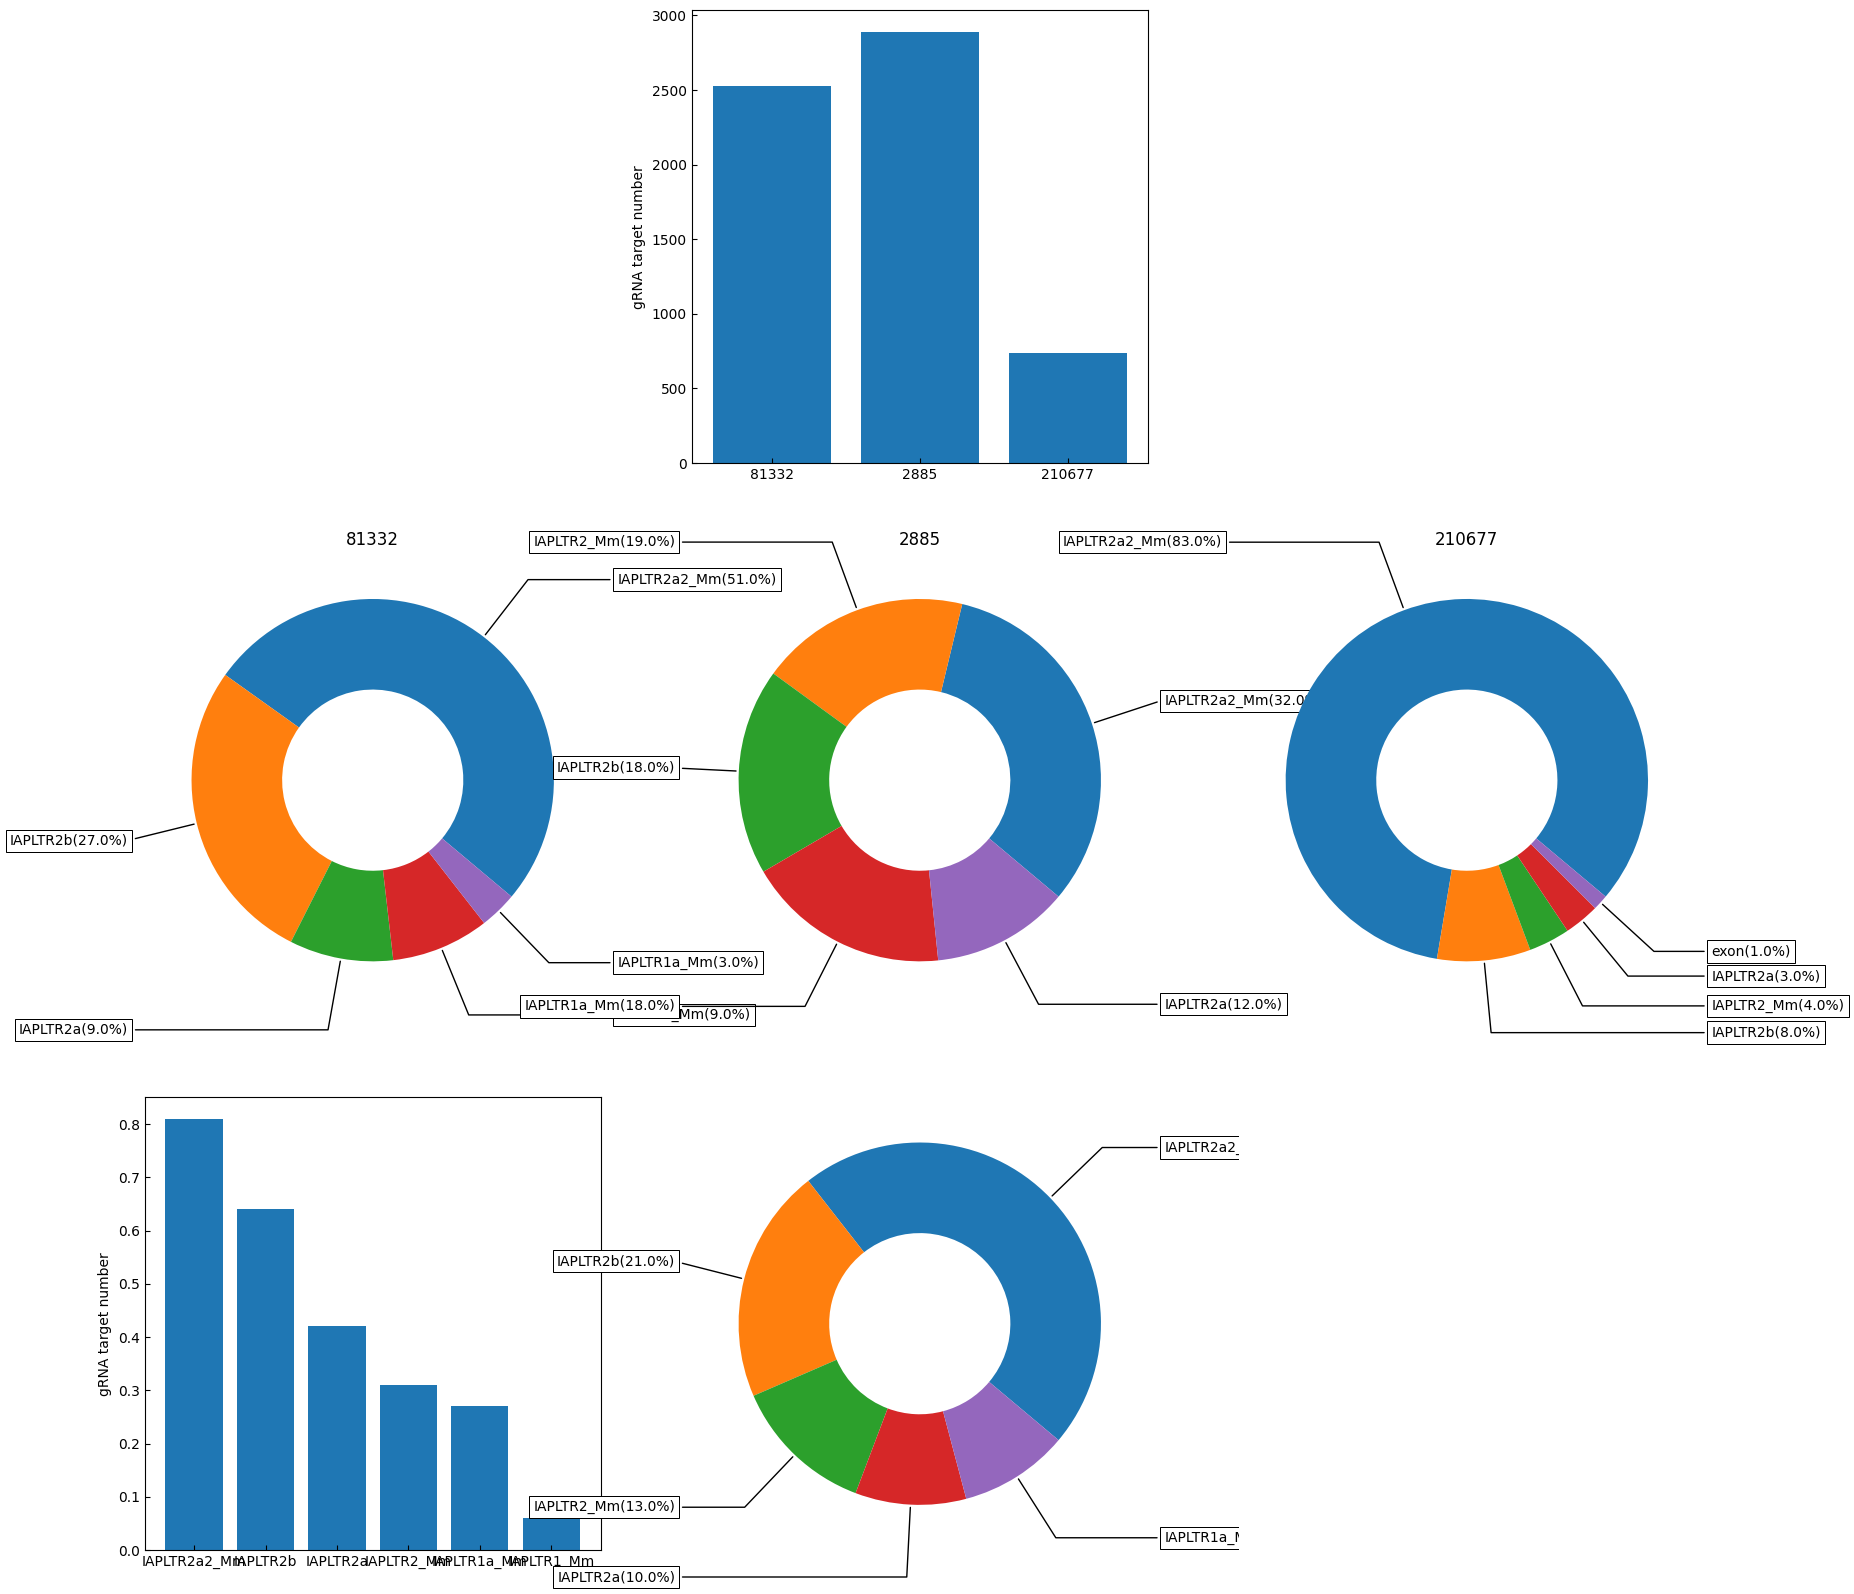

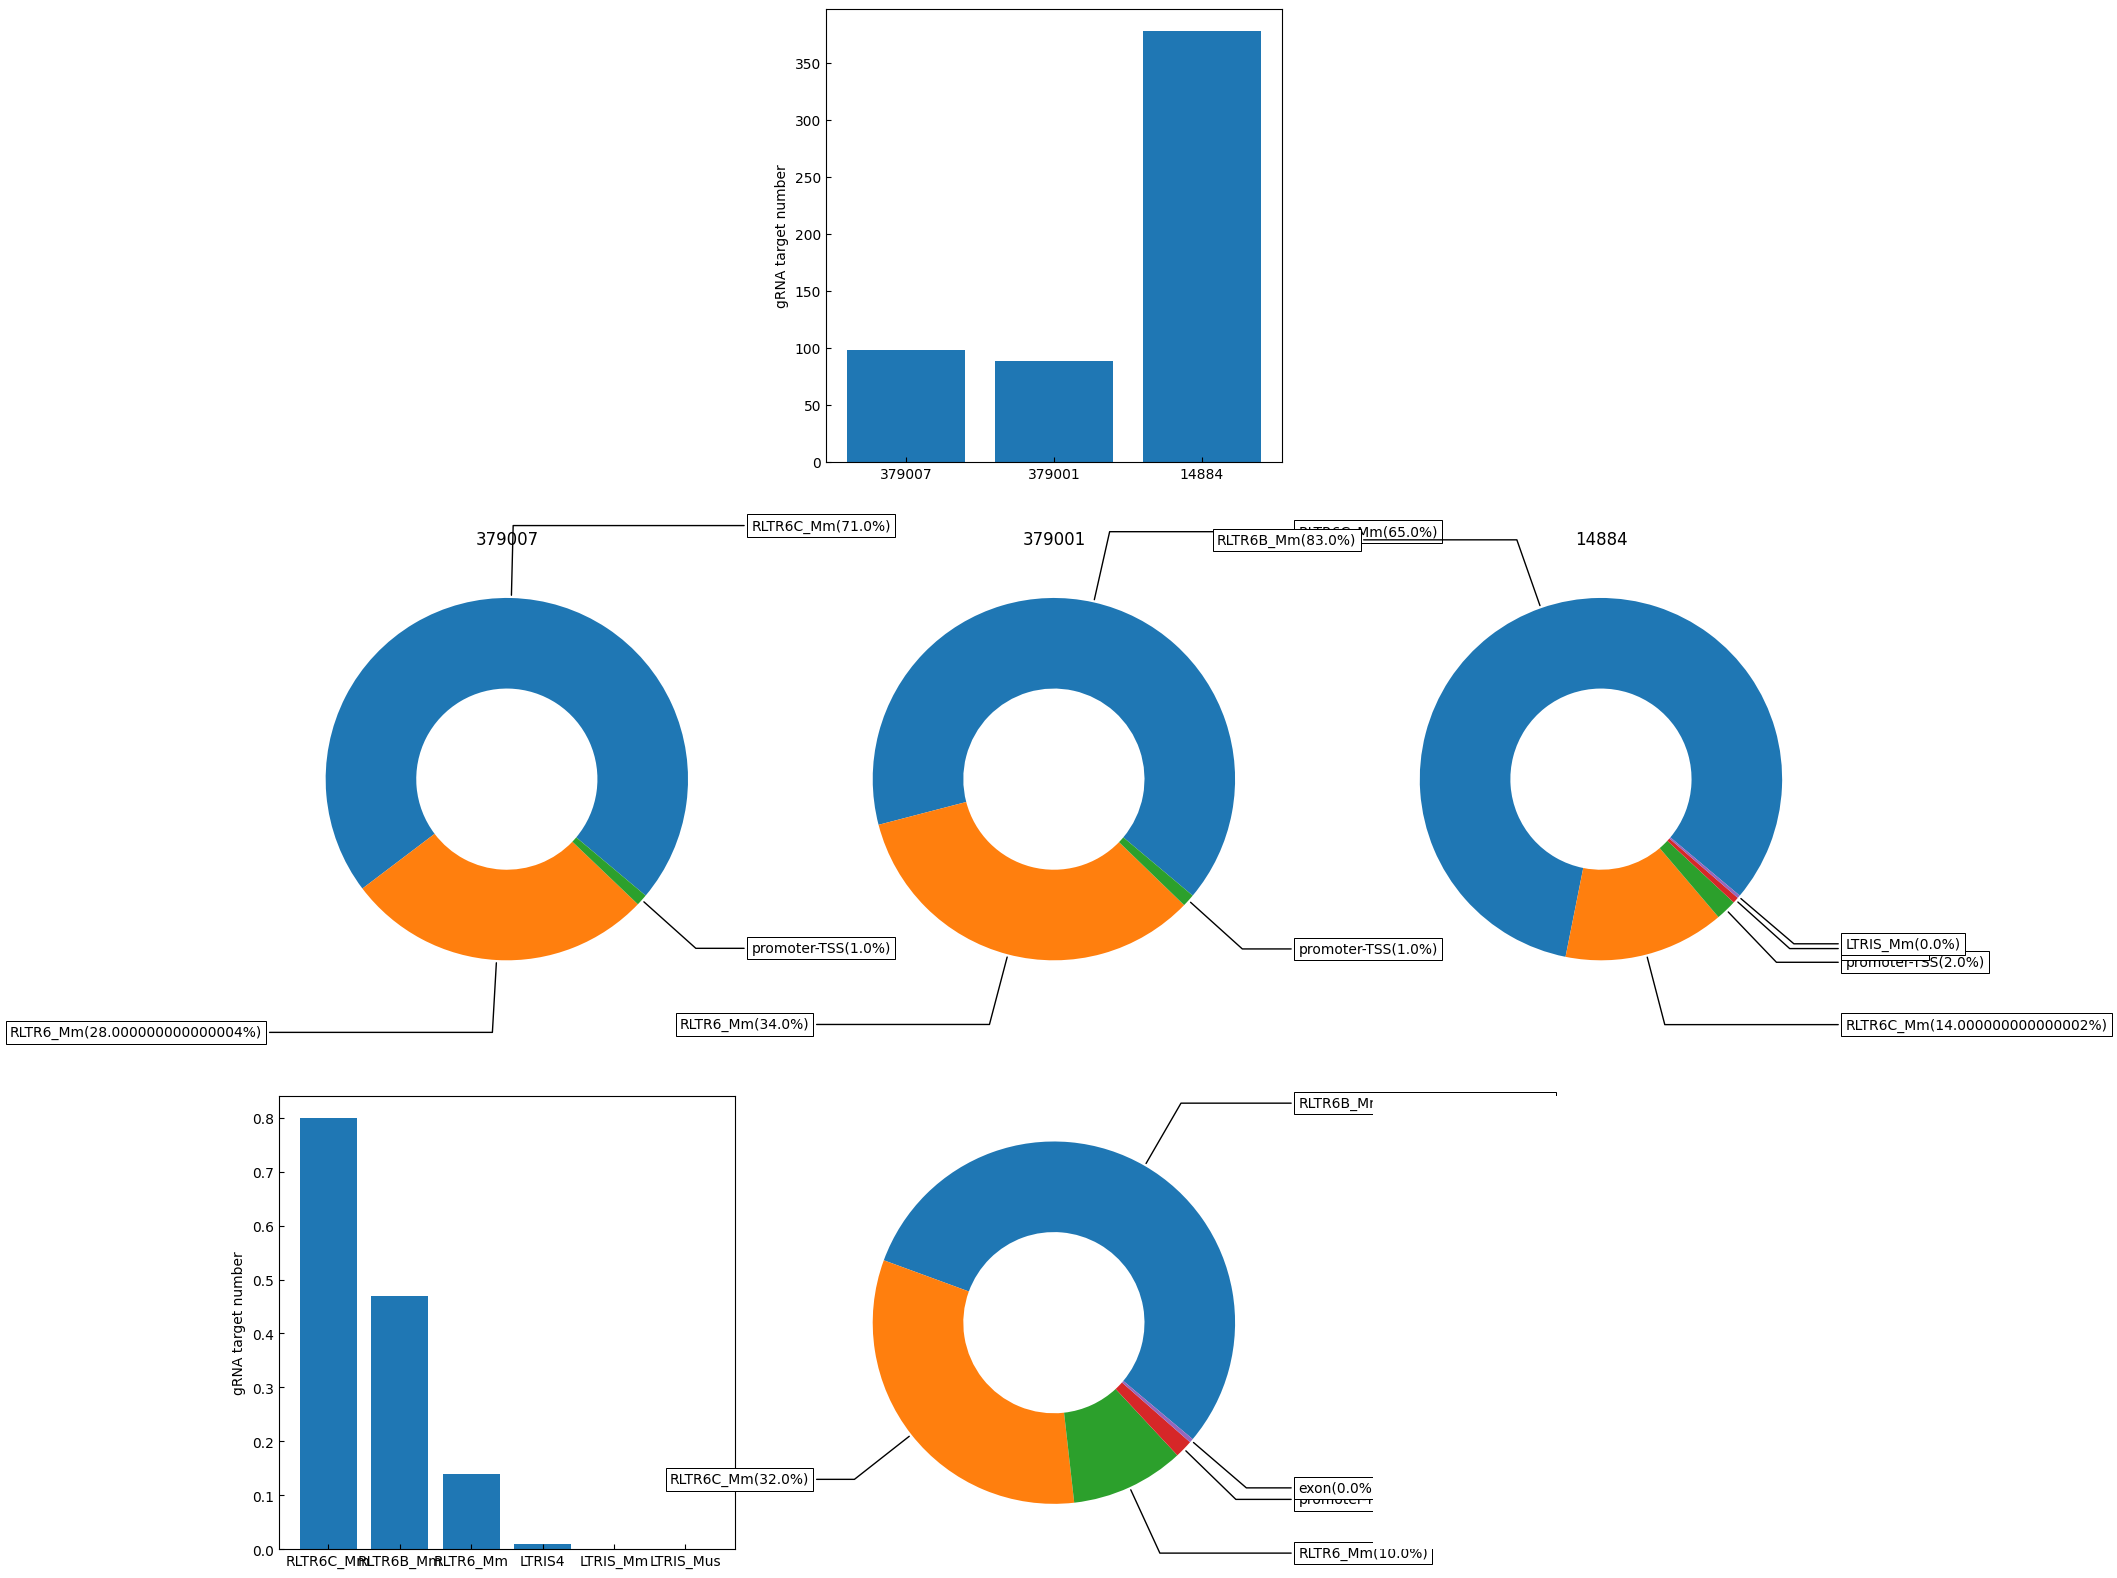

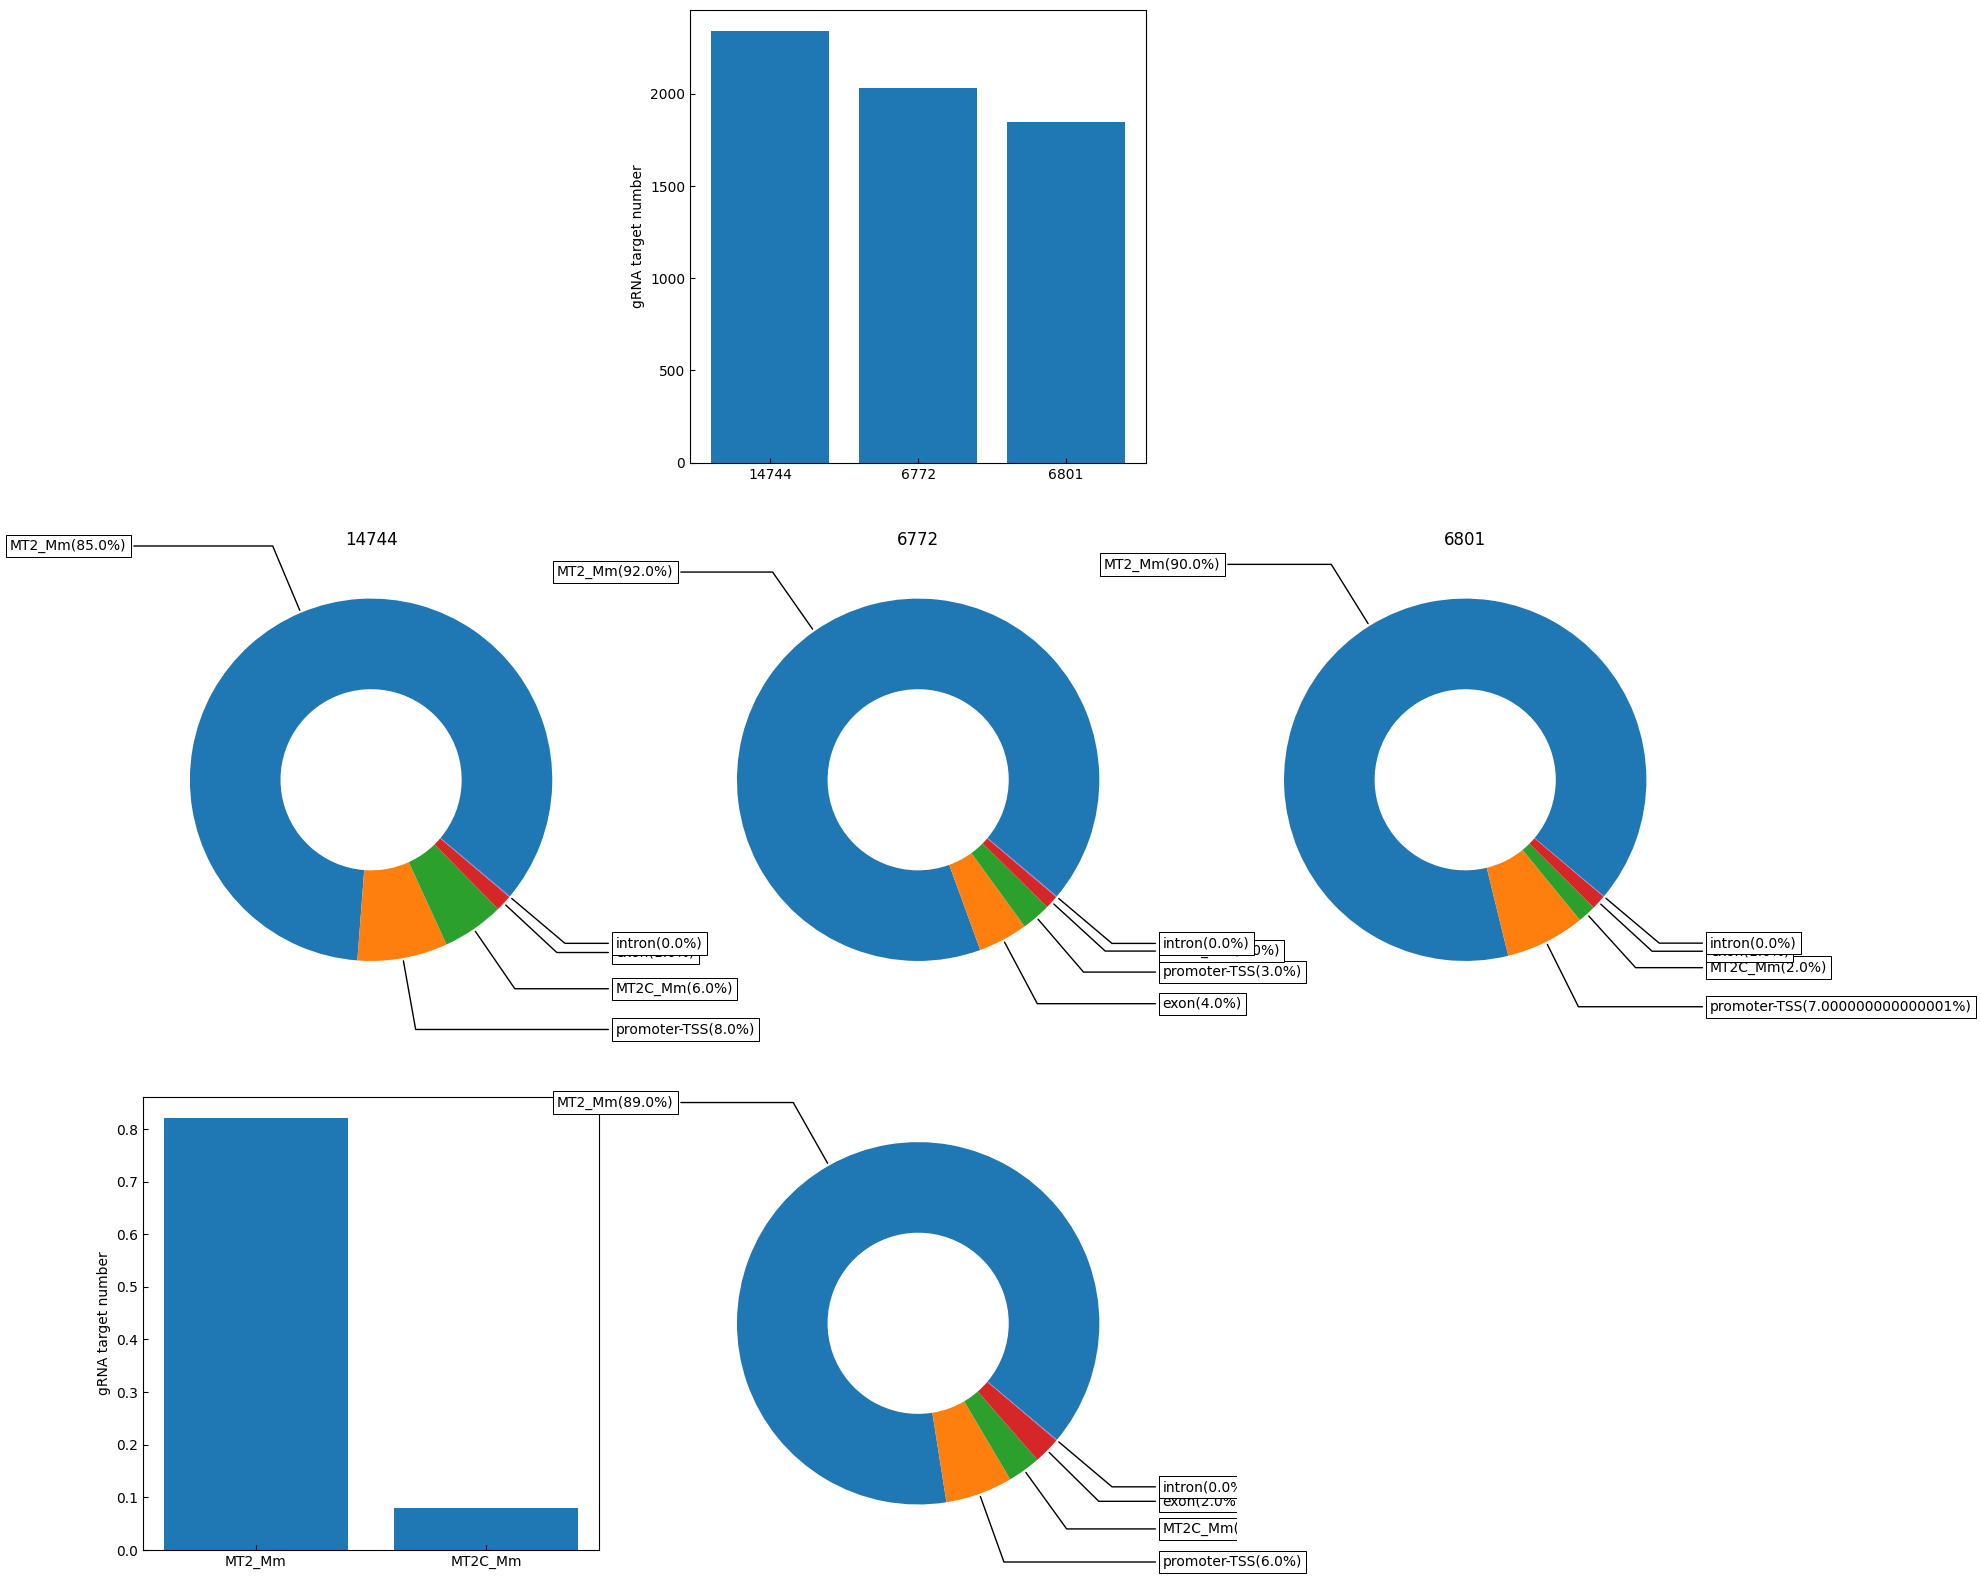

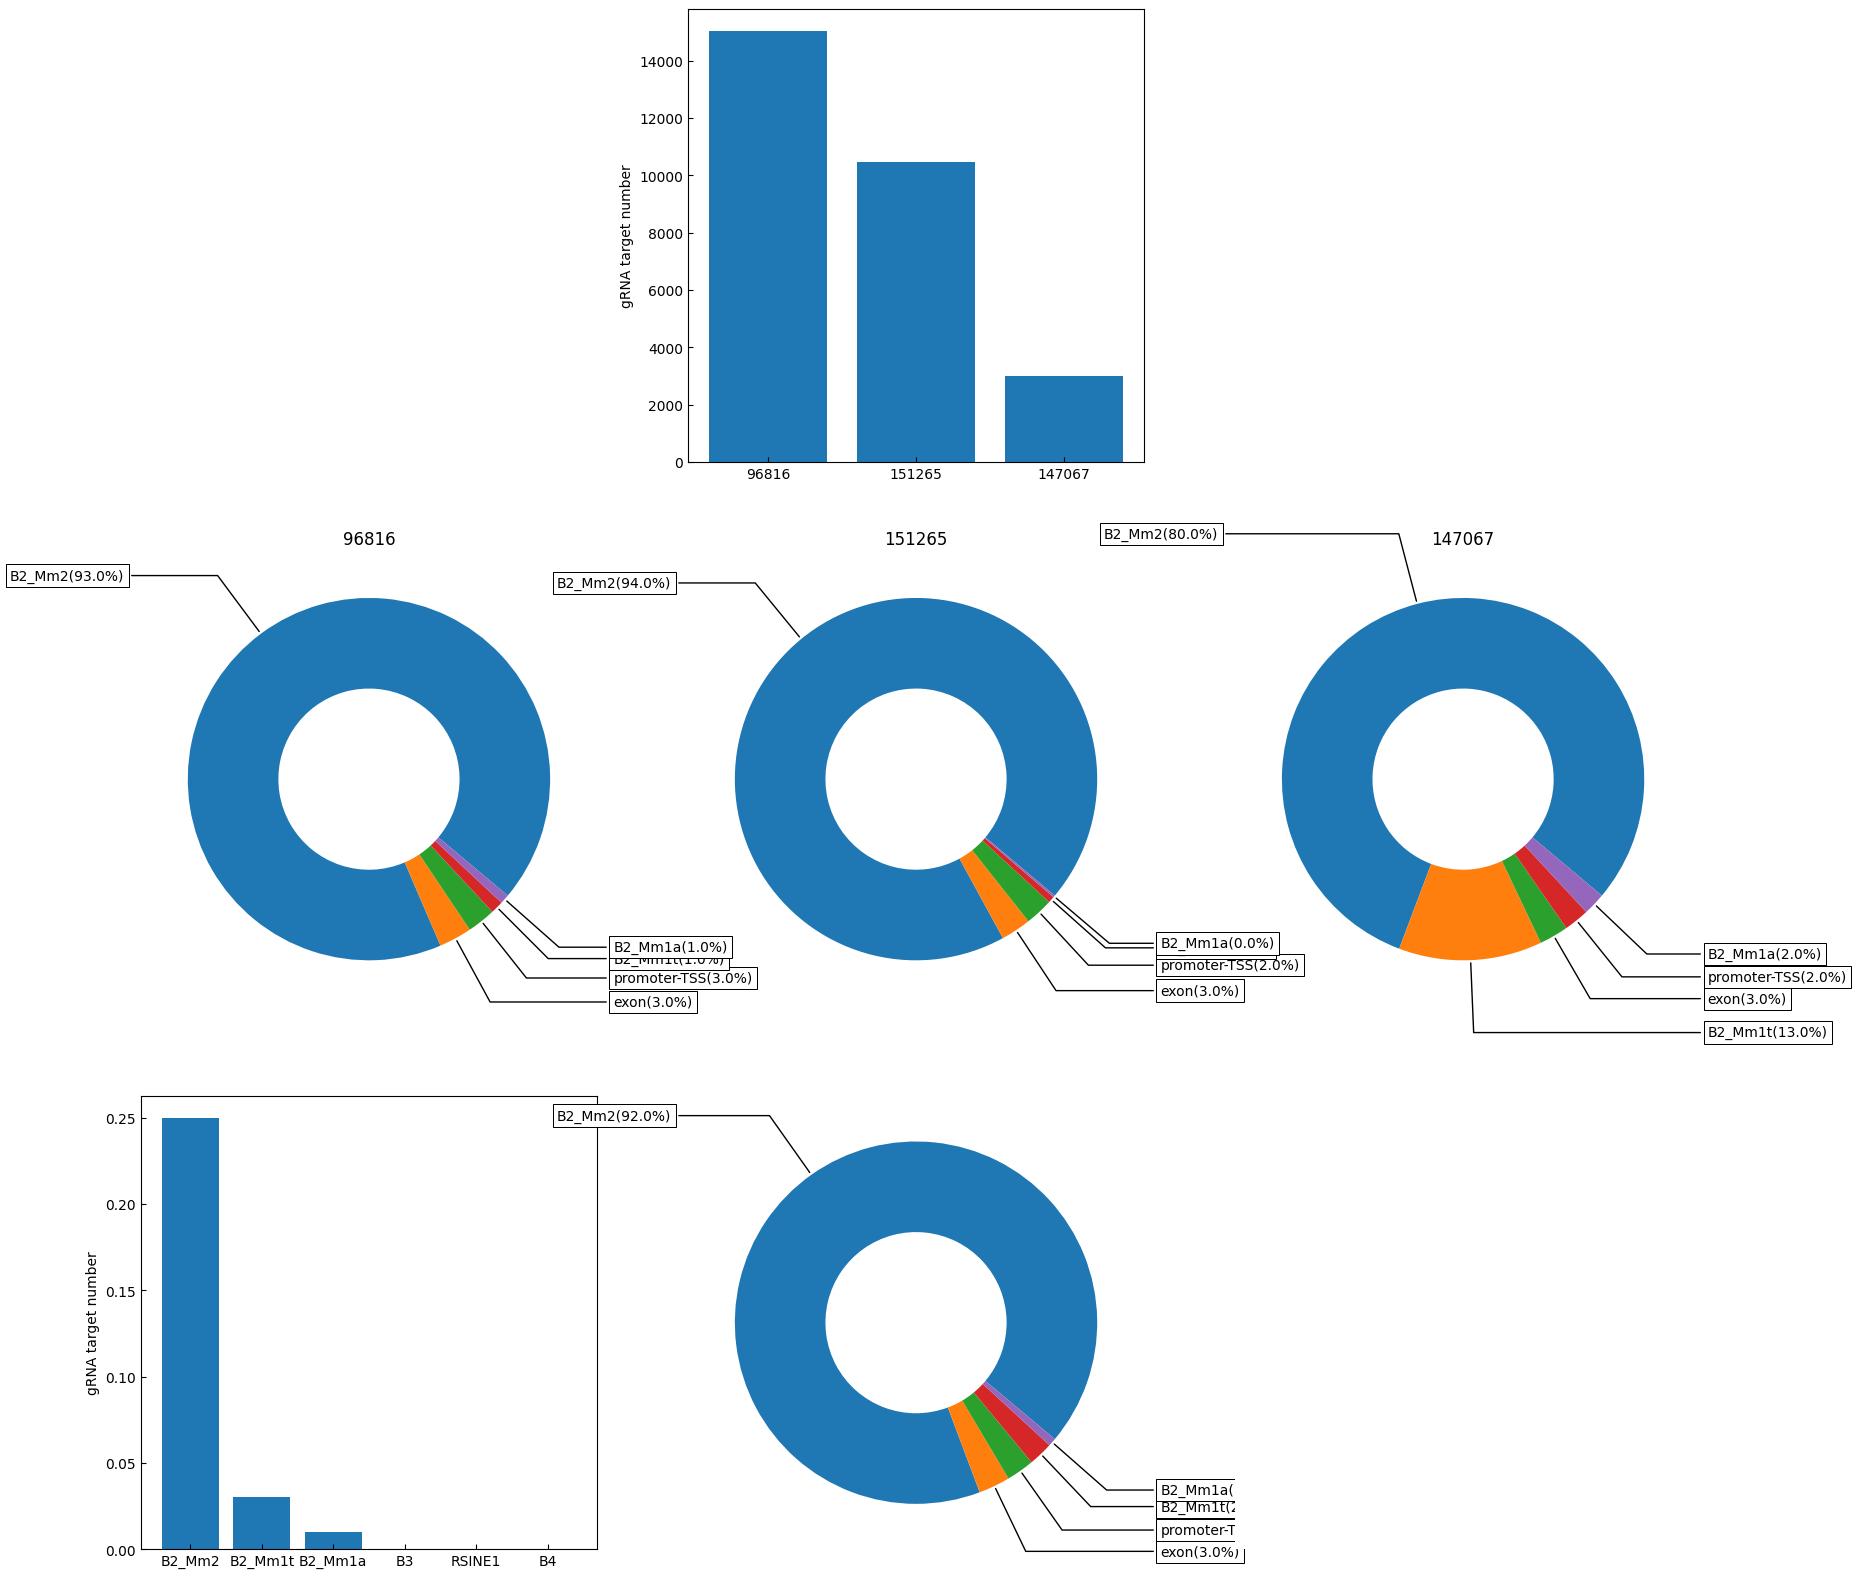

In [159]:
# LTR7Y_gids = [35075, 1387056, 35053]
for g,v in mouse_TE.items():
# g = 'IAPLTR2a2_Mm'
# v = [81332, 2885, 210677]
    LTR7Y_annotation_dict = {}
    print(g)
    for gid in v:
        # print(gid)
        gid_info_gseq = PGSQL.select_gid_anno_table1_gid(mm10_cursor, gid)
        # print(len(gid_info_gseq))
        allinfo_pd = pd.DataFrame()
        allinfo_pd['AnnotationType'] = [parseGidAnno2(x[1].tobytes().decode()) for x in gid_info_gseq]
        allinfo_pd['DetailedType'] = [parseGidAnno3(x[1].tobytes().decode()) for x in gid_info_gseq]
        # print(allinfo_pd.shape)
        # allinfo_pd['TEType'] = [i[8] for i in gid_info_gseq]
        # allinfo_pd['DetailtedInfo'] = [i[9] for i in gid_info_gseq]
        LTR7Y_annotation_dict[gid] = allinfo_pd
        
    fig, axes = plt.subplots(3,3)
    fig.set_size_inches(20,20)
    ## barplot
    Barplot_data = []
    Barplot_label = []
    for k,v in LTR7Y_annotation_dict.items():

        Barplot_data.append(v.shape[0])
        Barplot_label.append(str(k))
    # fig = plt.p
    # filename = 'SVA_D_eachgRNA_target_number.pdf'
    myBar(Barplot_data, Barplot_label, axes[0][1],'')


    for i,(k,v) in enumerate(LTR7Y_annotation_dict.items()):
        pie_data, pie_label = processAnnotaionForPie(v['AnnotationType'].to_list())
        # print((pie_data, pie_label))
        # filename = 'SVA_D_gid' + str(k) + '_pie.pdf'
        if i<3:
            myPie(pie_data, pie_label, axes[1][i%3], str(k))
        else:
            myPie(pie_data, pie_label, axes[2][i%3], str(k))

    combination_pie_data, combination_pie_label = processAnnotaion_combination(LTR7Y_annotation_dict)
    combination_Barplot_data, combination_Barplot_label = get_combination_barplot(LTR7Y_annotation_dict)
    myBar(combination_Barplot_data, combination_Barplot_label, axes[2][0],'')

    myPie(combination_pie_data, combination_pie_label, axes[2][1],'')

    for ax in [axes[0,0],axes[0,2], axes[2,2]]:
        ax.spines['right'].set_color('none')     
        ax.spines['top'].set_color('none')
        ax.spines['bottom'].set_color('none')     
        ax.spines['left'].set_color('none')
        ax.set_xticks([])
        ax.set_yticks([])
    fig.savefig('202301011_{}_annotation.pdf'.format(g))


/tmp/ipykernel_219857/54932318.py:37: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  total_pd = total_pd.append(v)


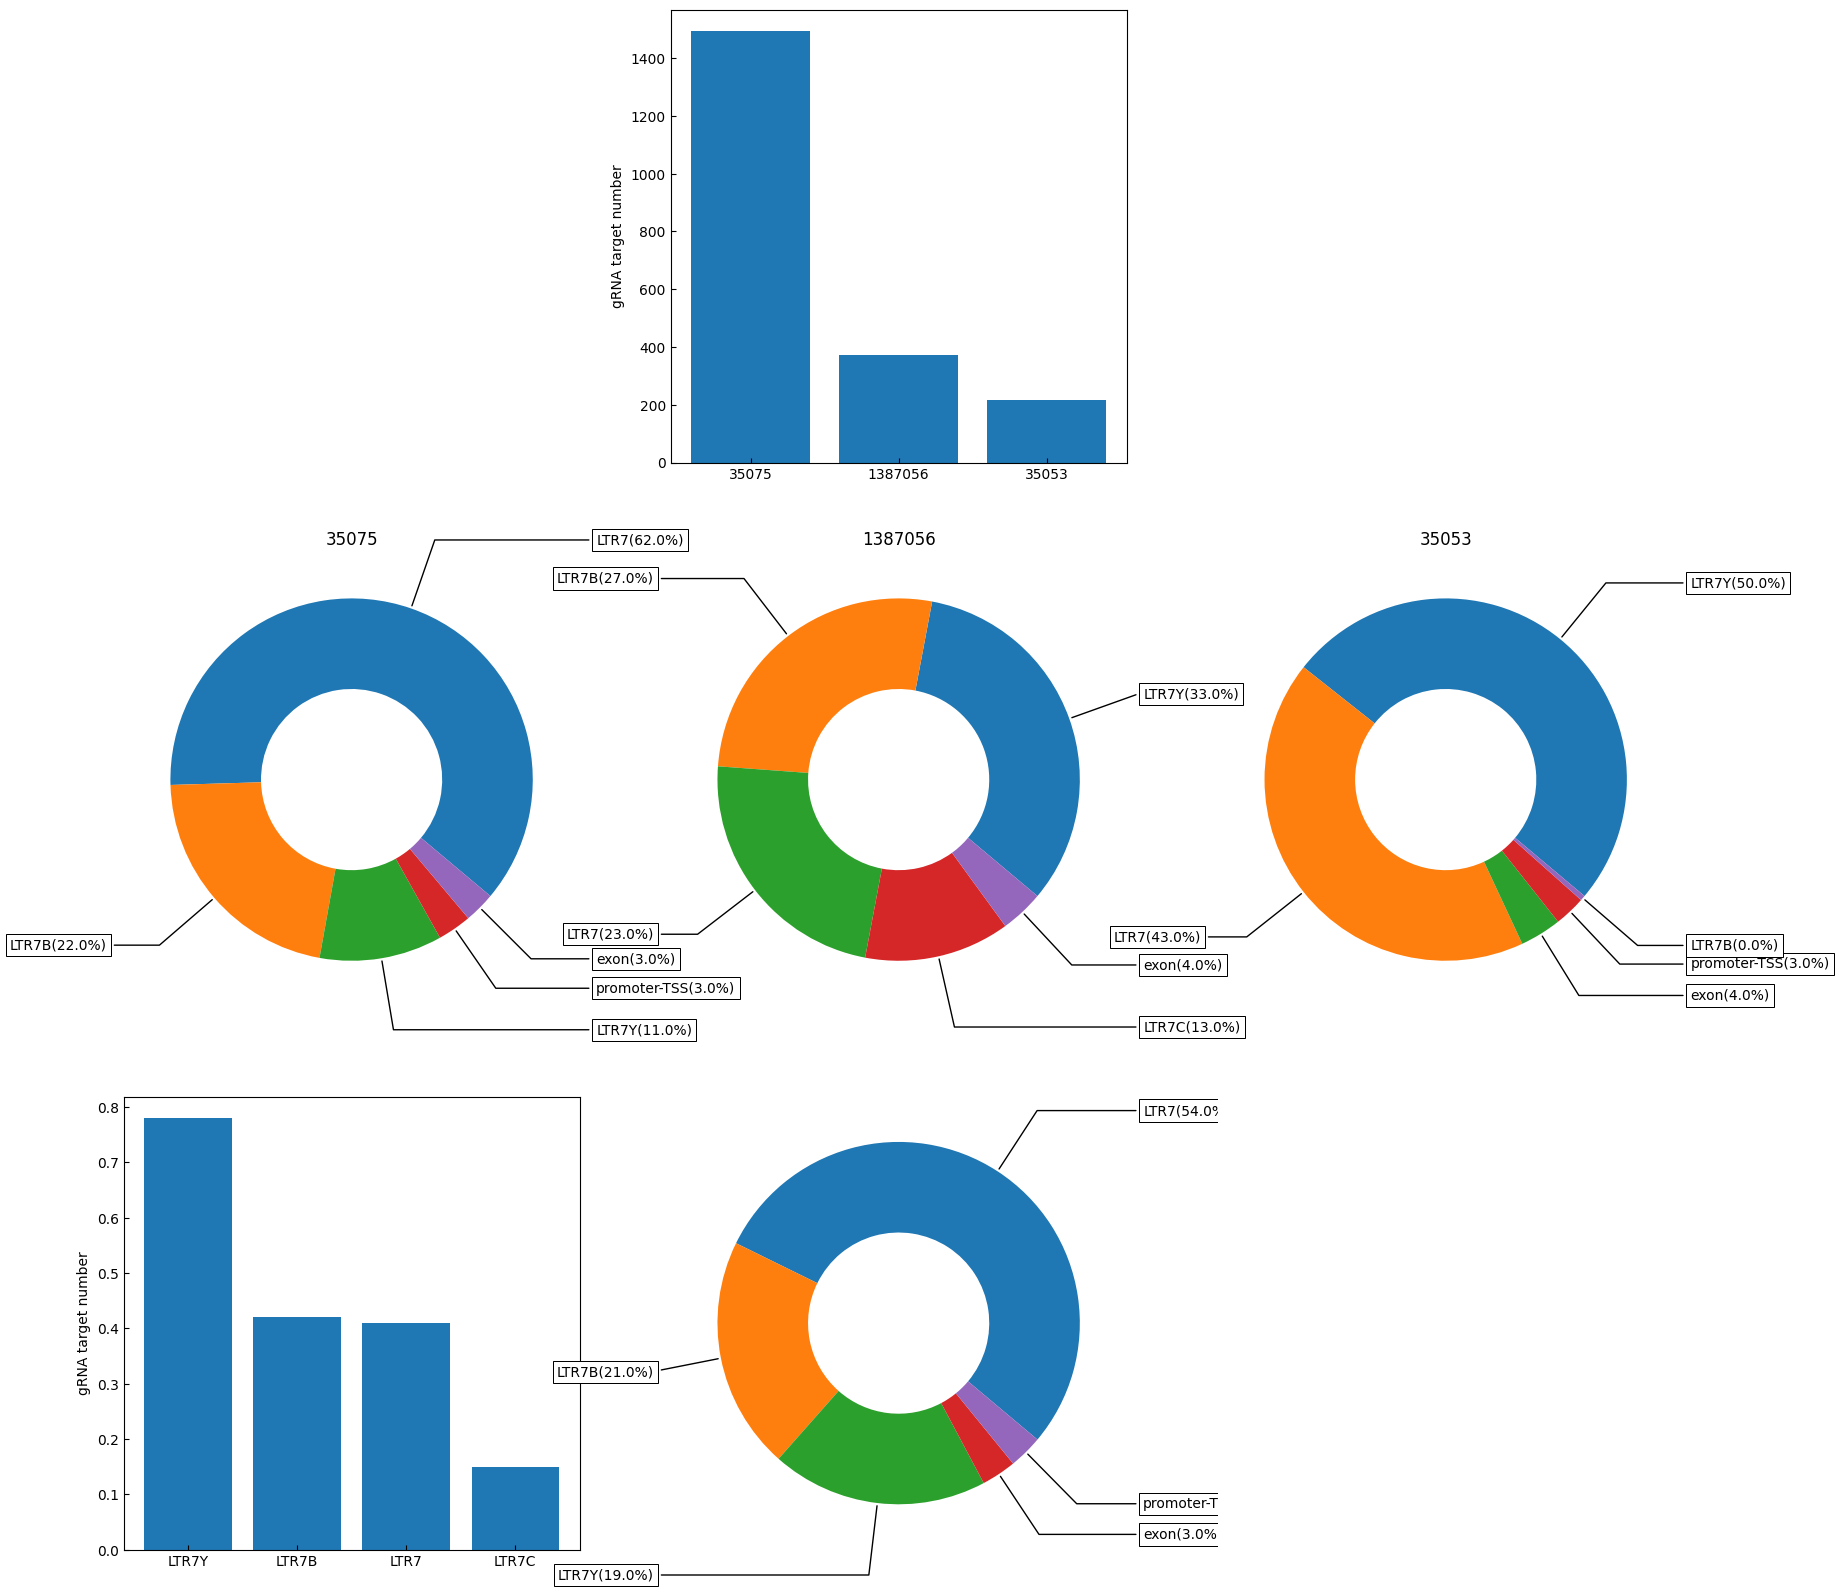

In [124]:
fig, axes = plt.subplots(3,3)
fig.set_size_inches(20,20)
## barplot
Barplot_data = []
Barplot_label = []
for k,v in LTR7Y_annotation_dict.items():

    Barplot_data.append(v.shape[0])
    Barplot_label.append(str(k))
# fig = plt.p
# filename = 'SVA_D_eachgRNA_target_number.pdf'
myBar(Barplot_data, Barplot_label, axes[0][1],'')


for i,(k,v) in enumerate(LTR7Y_annotation_dict.items()):
    pie_data, pie_label = processAnnotaionForPie(v['AnnotationType'].to_list())
    # print((pie_data, pie_label))
    # filename = 'SVA_D_gid' + str(k) + '_pie.pdf'
    if i<3:
        myPie(pie_data, pie_label, axes[1][i%3], str(k))
    else:
        myPie(pie_data, pie_label, axes[2][i%3], str(k))

combination_pie_data, combination_pie_label = processAnnotaion_combination(LTR7Y_annotation_dict)
combination_Barplot_data, combination_Barplot_label = get_combination_barplot(LTR7Y_annotation_dict)
myBar(combination_Barplot_data, combination_Barplot_label, axes[2][0],'')

myPie(combination_pie_data, combination_pie_label, axes[2][1],'')

for ax in [axes[0,0],axes[0,2], axes[2,2]]:
    ax.spines['right'].set_color('none')     
    ax.spines['top'].set_color('none')
    ax.spines['bottom'].set_color('none')     
    ax.spines['left'].set_color('none')
    ax.set_xticks([])
    ax.set_yticks([])
fig.savefig('')


/tmp/ipykernel_219857/1008659123.py:36: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  total_pd = total_pd.append(v)
